# Read & Merge AHN data (raster)

In [5]:
import os
from rasterio.merge import merge
import rasterio
import numpy as np

In [77]:
# read TIFF files from folder (data\ahn5_raster_5m) and merged them into one single file
# file names: 2023_R5_20BZ1, 2023_R5_20BZ2, 2023_R5_20DN1, 2023_R5_20DN2

# src_dir = os.path.join("data", "ahn5_raster_5m")
# names = ["2023_R5_20BZ1", "2023_R5_20BZ2", "2023_R5_20DN1", "2023_R5_20DN2"]
# files = [os.path.join(src_dir, f"{n}.tiff") for n in names]

src_dir = os.path.join("data", "ahn4_raster_5m")
names = ["R5_20BZ1", "R5_20BZ2", "R5_20DN1", "R5_20DN2"]
files = [os.path.join(src_dir, f"{n}.tif") for n in names]

data\ahn4_raster_5m\R5_20BZ1.tif CRS: EPSG:28992
data\ahn4_raster_5m\R5_20BZ1.tif Bounds: BoundingBox(left=150000.0, bottom=512500.0, right=155000.0, top=518750.0)
data\ahn4_raster_5m\R5_20BZ1.tif Shape: (1250, 1000)
data\ahn4_raster_5m\R5_20BZ1.tif min: -0.2555663 max: 3.4028235e+38 nodata: 3.4028234663852886e+38
data\ahn4_raster_5m\R5_20BZ1.tif Value at (500, 500): 3.4028235e+38


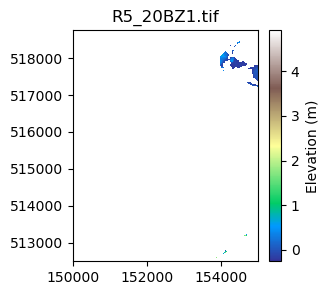

data\ahn4_raster_5m\R5_20BZ2.tif CRS: EPSG:28992
data\ahn4_raster_5m\R5_20BZ2.tif Bounds: BoundingBox(left=155000.0, bottom=512500.0, right=160000.0, top=518750.0)
data\ahn4_raster_5m\R5_20BZ2.tif Shape: (1250, 1000)
data\ahn4_raster_5m\R5_20BZ2.tif min: -0.29520953 max: 3.4028235e+38 nodata: 3.4028234663852886e+38
data\ahn4_raster_5m\R5_20BZ2.tif Value at (500, 500): 3.4028235e+38


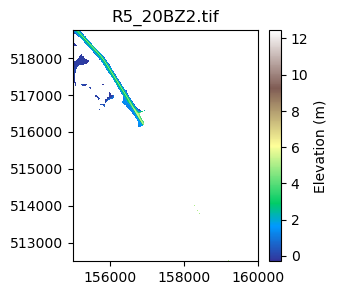

data\ahn4_raster_5m\R5_20DN1.tif CRS: EPSG:28992
data\ahn4_raster_5m\R5_20DN1.tif Bounds: BoundingBox(left=150000.0, bottom=506250.0, right=155000.0, top=512500.0)
data\ahn4_raster_5m\R5_20DN1.tif Shape: (1250, 1000)
data\ahn4_raster_5m\R5_20DN1.tif min: -0.67342323 max: 3.4028235e+38 nodata: 3.4028234663852886e+38
data\ahn4_raster_5m\R5_20DN1.tif Value at (500, 500): 3.4028235e+38


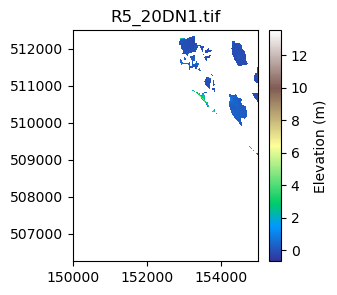

data\ahn4_raster_5m\R5_20DN2.tif CRS: EPSG:28992
data\ahn4_raster_5m\R5_20DN2.tif Bounds: BoundingBox(left=155000.0, bottom=506250.0, right=160000.0, top=512500.0)
data\ahn4_raster_5m\R5_20DN2.tif Shape: (1250, 1000)
data\ahn4_raster_5m\R5_20DN2.tif min: -5.431095 max: 3.4028235e+38 nodata: 3.4028234663852886e+38
data\ahn4_raster_5m\R5_20DN2.tif Value at (500, 500): 3.4028235e+38


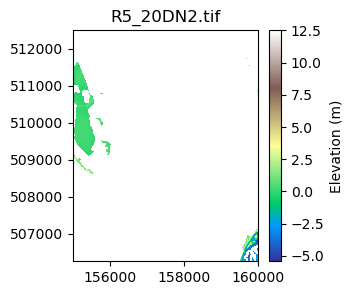

In [78]:
# plot each file
import matplotlib.pyplot as plt
from rasterio.plot import show
for fp in files:
    with rasterio.open(fp) as src:
        # print CRS, bounds, shape
        print(fp, "CRS:", src.crs)
        print(fp, "Bounds:", src.bounds)
        print(fp, "Shape:", src.shape)
        # print min, max, nodata
        arr = src.read(1)
        print(fp, "min:", arr.min(), "max:", arr.max(), "nodata:", src.nodata)
        # print value at pixels y_min+500 and x_min+500
        arr = src.read(1)
        print(fp, "Value at (500, 500):", arr[500, 500])


        fig, ax = plt.subplots(figsize=(3, 3))
        show(src, ax=ax, cmap='terrain')
        ax.set_title(os.path.basename(fp))
        # add legend
        plt.colorbar(ax.images[0], ax=ax, orientation='vertical', label='Elevation (m)')
        plt.show()

In [79]:
# handle nodata values
for fp in files:
    with rasterio.open(fp) as src:
        arr = src.read(1)
        print(fp, "min:", arr.min(), "max:", arr.max(), "nodata:", src.nodata)
        # set nodata values to nan
        arr = src.read(1)
        arr[arr == src.nodata] = np.nan
        print(fp, "After setting nodata to nan, min:", np.nanmin(arr), "max:", np.nanmax(arr))
        # print value at pixels y_min+500 and x_min+500
        print(fp, "Value at (500, 500):", arr[500, 500])

data\ahn4_raster_5m\R5_20BZ1.tif min: -0.2555663 max: 3.4028235e+38 nodata: 3.4028234663852886e+38
data\ahn4_raster_5m\R5_20BZ1.tif After setting nodata to nan, min: -0.2555663 max: 4.914655
data\ahn4_raster_5m\R5_20BZ1.tif Value at (500, 500): nan
data\ahn4_raster_5m\R5_20BZ2.tif min: -0.29520953 max: 3.4028235e+38 nodata: 3.4028234663852886e+38
data\ahn4_raster_5m\R5_20BZ2.tif After setting nodata to nan, min: -0.29520953 max: 12.4522705
data\ahn4_raster_5m\R5_20BZ2.tif Value at (500, 500): nan
data\ahn4_raster_5m\R5_20DN1.tif min: -0.67342323 max: 3.4028235e+38 nodata: 3.4028234663852886e+38
data\ahn4_raster_5m\R5_20DN1.tif After setting nodata to nan, min: -0.67342323 max: 13.542089
data\ahn4_raster_5m\R5_20DN1.tif Value at (500, 500): nan
data\ahn4_raster_5m\R5_20DN2.tif min: -5.431095 max: 3.4028235e+38 nodata: 3.4028234663852886e+38
data\ahn4_raster_5m\R5_20DN2.tif After setting nodata to nan, min: -5.431095 max: 12.507668
data\ahn4_raster_5m\R5_20DN2.tif Value at (500, 500): na

In [80]:
# print data from files[0]
with rasterio.open(files[0]) as src:
    arr = src.read(1)
    print("Data type:", arr.dtype)
    print("Min value:", arr.min())
    print("Max value:", arr.max())
    print("NoData value:", src.nodata)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Transform:", src.transform)
    print("Shape:", arr.shape)

    # count number of NoData values
    nodata_count = (arr == src.nodata).sum()
    print("NoData count:", nodata_count)
    # percentage of NoData values
    nodata_percentage = nodata_count / arr.size
    print("NoData percentage:", nodata_percentage * 100)

Data type: float32
Min value: -0.2555663
Max value: 3.4028235e+38
NoData value: 3.4028234663852886e+38
CRS: EPSG:28992
Bounds: BoundingBox(left=150000.0, bottom=512500.0, right=155000.0, top=518750.0)
Transform: | 5.00, 0.00, 150000.00|
| 0.00,-5.00, 518750.00|
| 0.00, 0.00, 1.00|
Shape: (1250, 1000)
NoData count: 1222865
NoData percentage: 97.8292


In [81]:
# handle nodata before merging: read arrays, replace nodata with np.nan,
# then create in-memory datasets from the (array, transform) pairs and merge them.
# Some rasterio versions expect dataset objects (not plain tuples), which caused:
# AttributeError: 'tuple' object has no attribute 'profile'

# build array+transform pairs
srcs = [rasterio.open(fp) for fp in files]
pairs = []
for s in srcs:
	a = s.read(1).astype('float32')
	if s.nodata is not None:
		a[a == s.nodata] = np.nan
	pairs.append((a, s.transform))
for s in srcs:
	s.close()

# create MemoryFile datasets from pairs and merge them
mem_files = []
mem_ds = []
for a, transform in pairs:
	profile = {
		'driver': 'GTiff',
		'height': a.shape[0],
		'width': a.shape[1],
		'count': 1,
		'dtype': 'float32',
		'transform': transform,
		# reuse the CRS from an existing profile if available
		'crs': out_meta.get('crs') if 'out_meta' in globals() else None
	}
	mem = rasterio.io.MemoryFile()
	dst = mem.open(**{k: v for k, v in profile.items() if v is not None})
	# write expects a 2D array for one band
	dst.write(a, 1)
	mem_files.append(mem)
	mem_ds.append(dst)

# perform merge on dataset objects
final_mosaic, final_transform = merge(mem_ds, method='first')

# close memory datasets/files
for dst in mem_ds:
	dst.close()
for mem in mem_files:
	mem.close()

print("Final mosaic shape:", final_mosaic.shape)


Final mosaic shape: (1, 2500, 2000)


In [82]:
# print resolution
print("Final mosaic resolution:", final_transform.a, final_transform.e)

Final mosaic resolution: 5.0 -5.0


In [83]:
# final_mosaic

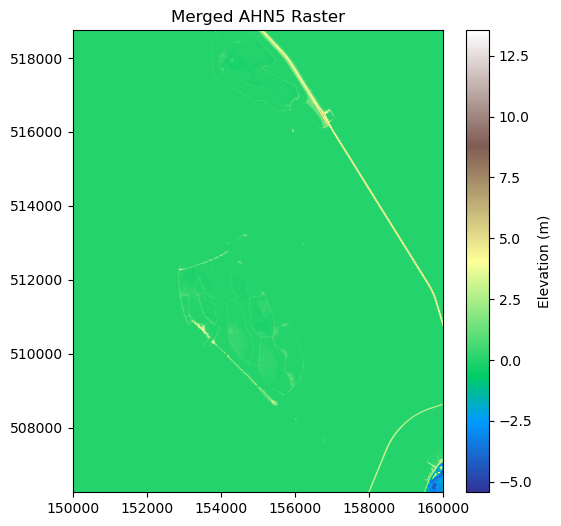

In [84]:
# plot final_mosaic
fig, ax = plt.subplots(figsize=(6, 6))
show(final_mosaic, transform=final_transform, ax=ax, cmap='terrain')
ax.set_title("Merged AHN5 Raster")
# add legend
plt.colorbar(ax.images[0], ax=ax, orientation='vertical', label='Elevation (m)')
plt.show()

In [85]:
# crop min_x=151800, min_y=508000, max_x=157800, max_y=514000
min_x, min_y, max_x, max_y = 151800, 508000, 157800, 514000
col_start, row_start = ~final_transform * (min_x, max_y)
col_stop, row_stop = ~final_transform * (max_x, min_y)
row_start, col_start = map(int, map(np.floor, (row_start, col_start)))
row_stop, col_stop = map(int, map(np.ceil, (row_stop, col_stop)))
cropped_mosaic = final_mosaic[:, row_start:row_stop, col_start:col_stop]
cropped_mosaic.shape

(1, 1200, 1200)

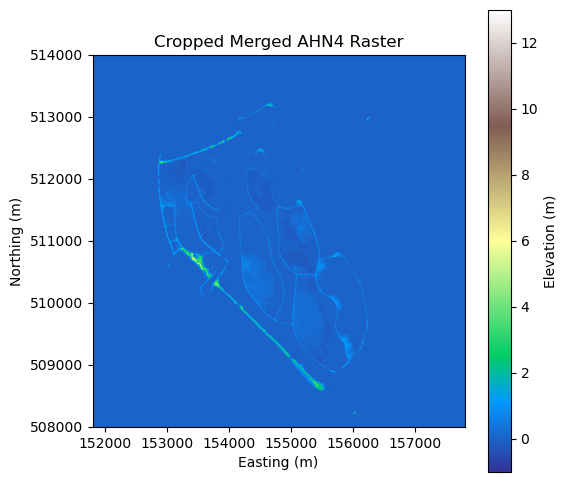

In [87]:
# compute georeferenced transform for the cropped window
t = final_transform
new_c = t.c + col_start * t.a + row_start * t.b
new_f = t.f + col_start * t.d + row_start * t.e
cropped_transform = type(t)(t.a, t.b, new_c, t.d, t.e, new_f)

fig, ax = plt.subplots(figsize=(6, 6))
show(cropped_mosaic, transform=cropped_transform, ax=ax, cmap='terrain')
ax.set_title("Cropped Merged AHN4 Raster")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
# set colorbar limits and add colorbar
img = ax.images[0]
img.set_clim(-1, 13)
plt.colorbar(img, ax=ax, orientation='vertical', label='Elevation (m)')
plt.show()
plt.show()

In [63]:
# save cropped_mosaic to GeoTIFF
out_fp = os.path.join("data/ahn4_raster_5m", "ahn4_merged_cropped.tiff")
with rasterio.open(out_fp, 'w', driver='GTiff',
                   height=cropped_mosaic.shape[1],
                   width=cropped_mosaic.shape[2],
                   count=cropped_mosaic.shape[0],
                   dtype=cropped_mosaic.dtype,
                   crs=srcs[0].crs,  # reuse CRS from one of the source files
                   transform=cropped_transform) as dst:
    dst.write(cropped_mosaic)

Cropped raster shape: (1, 1200, 1200)
Cropped raster transform: | 5.00, 0.00, 151800.00|
| 0.00,-5.00, 514000.00|
| 0.00, 0.00, 1.00|
Cropped raster CRS: EPSG:28992


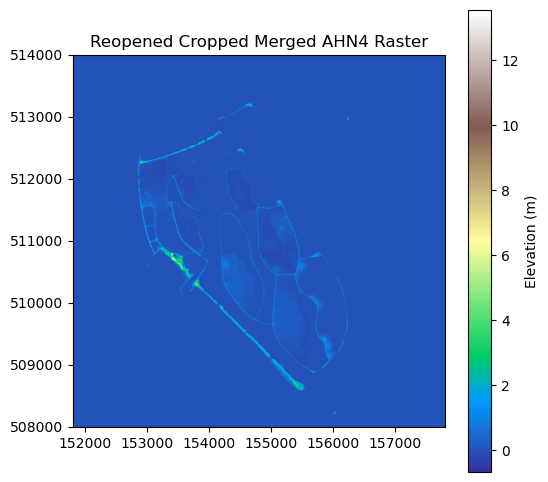

In [65]:
# open data/ahn4_raster_5m/ahn4_merged_cropped.tiff

path = os.path.join("data", "ahn4_raster_5m", "ahn4_merged_cropped.tiff")

with rasterio.open(path) as src:
    merged_cropped = src.read()
    merged_cropped_transform = src.transform
    print("Cropped raster shape:", merged_cropped.shape)
    print("Cropped raster transform:", merged_cropped_transform)
    print("Cropped raster CRS:", src.crs)
    
    # plot merged_cropped
    fig, ax = plt.subplots(figsize=(6, 6))
    show(merged_cropped, transform=merged_cropped_transform, ax=ax, cmap='terrain')
    ax.set_title("Reopened Cropped Merged AHN4 Raster")
    plt.colorbar(ax.images[0], ax=ax, orientation='vertical', label='Elevation (m)')
    plt.show()